## **Classification task: Classical Classification on CIFAR-10**

In [7]:
!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
!tar -xvzf cifar-10-python.tar.gz

--2026-03-17 16:39:15--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz.4’

cifar-10-python.tar 100%[===================>] 162.60M  12.9MB/s    in 10s     

2026-03-17 16:39:25 (16.1 MB/s) - ‘cifar-10-python.tar.gz.4’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


In [21]:
import os
import numpy as np
import pickle

# Function to load CIFAR-10 batches
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

# Define the data directory path
data_dir = 'cifar-10-batches-py'

# 1. Load ALL 5 training batches to get 50,000 images
X_train_list, y_train_list = [], []
for i in range(1, 6):
    batch_path = os.path.join(data_dir, f'data_batch_{i}')
    batch = unpickle(batch_path)
    X_train_list.append(batch[b'data'])
    y_train_list.extend(batch[b'labels'])

# 2. Combine all training batches into X_batch (50,000 images)
X_batch = np.concatenate(X_train_list).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_batch = np.array(y_train_list)

# 3. Load the test batch separately (The remaining 10,000 images)
test_batch_path = os.path.join(data_dir, 'test_batch')
test_batch = unpickle(test_batch_path)
X_test_raw = test_batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_test_raw = np.array(test_batch[b'labels'])

print(f"Success! Total Training/Val data: {X_batch.shape[0]} images.")
print(f"Success! Total Test data: {X_test_raw.shape[0]} images.")
print(f"Total dataset size: {X_batch.shape[0] + X_test_raw.shape[0]} images.")

Success! Total Training/Val data: 50000 images.
Success! Total Test data: 10000 images.
Total dataset size: 60000 images.


**Baseline Models**

Data Preprocessing & Preparation

In [22]:
# 1. Flatten the images: from (50000, 32, 32, 3) to (50000, 3072)
X_flatten = X_batch.reshape(X_batch.shape[0], -1)

# 2. Normalize the pixel values to range [0, 1]
X_normalized = X_flatten.astype('float32') / 255.0

# 3. Use the labels as they are
y_labels = y_batch

print(f"Data is ready for training.")
print(f"Original shape: {X_batch.shape}")
print(f"Flattened shape: {X_normalized.shape}")

Data is ready for training.
Original shape: (50000, 32, 32, 3)
Flattened shape: (50000, 3072)


In [23]:
from sklearn.model_selection import train_test_split

# Create a single, consistent Train/Validation split (80% Train, 20% Validation)
# This strictly follows the instruction: "Each model must be trained using the same train/validation split"
X_train_val, X_val, y_train_val, y_val = train_test_split(
    X_normalized, y_labels, test_size=0.2, random_state=42
)

print(f"Consistent split created")
print(f"Training set size: {X_train_val.shape[0]} images")
print(f"Validation set size: {X_val.shape[0]} images")

Consistent split created
Training set size: 40000 images
Validation set size: 10000 images


 Multiclass Logistic Regression (Softmax)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Define the baseline model using Multinomial (Softmax)
# Changed solver to 'saga' which is much faster for large image datasets
softmax_model = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=500, tol=0.1, random_state=42, n_jobs=-1)

# 2. Train the model ONLY on the Training set!
softmax_model.fit(X_train_val, y_train_val)

# 3. Make predictions on the VALIDATION set
y_val_pred_softmax = softmax_model.predict(X_val)

# 4. Evaluate the performance on the Validation set
accuracy_softmax = accuracy_score(y_val, y_val_pred_softmax)
print(f"Baseline Softmax Validation Accuracy: {accuracy_softmax * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Baseline Softmax Validation Accuracy: 41.59%


Linear Support Vector Machine (SVM)

In [25]:
from sklearn.svm import LinearSVC

# Define the Linear SVM model
# We use dual=False because we have more samples than features
svm_model = LinearSVC(dual=False, max_iter=500, tol=0.1, verbose=1, random_state=42)

# Train the model on the full normalized batch
svm_model.fit(X_train_val, y_train_val)

# Predict and Evaluate
y_val_pred_svm = svm_model.predict(X_val)
acc_svm = accuracy_score(y_val, y_val_pred_svm)

print(f"Linear SVM Accuracy: {acc_svm * 100:.2f}%")

[LibLinear]Linear SVM Accuracy: 35.22%


K-Nearest Neighbors (KNN)

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Define the KNN model
# We use n_jobs=-1 to use all CPU cores for distance calculations
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

# 2. Fit the model (This is almost instant)
print("Fitting KNN...")
knn_model.fit(X_train_val, y_train_val)

# 3. Predict on Validation set
# WARNING: Predicting 10,000 images against 40,000 images is heavy.
print("Predicting... This may take around 10 minutes.")
y_val_pred_knn = knn_model.predict(X_val)

# 4. Evaluate
accuracy_knn = accuracy_score(y_val, y_val_pred_knn)
print(f"Baseline KNN Validation Accuracy: {accuracy_knn * 100:.2f}%")

Fitting KNN...
Predicting... This may take around 10 minutes.
Baseline KNN Validation Accuracy: 33.25%


 **Hyperparameter Selection**





Hyperparameter Selection - Softmax (Regularization C)

Starting Hyperparameter Selection...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C = 0.01, accuracy = 0.4183


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C = 0.1, accuracy = 0.4041


...

C = 1, accuracy = 0.4003


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C = 10, accuracy = 0.4001


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C = 100, accuracy = 0.4001


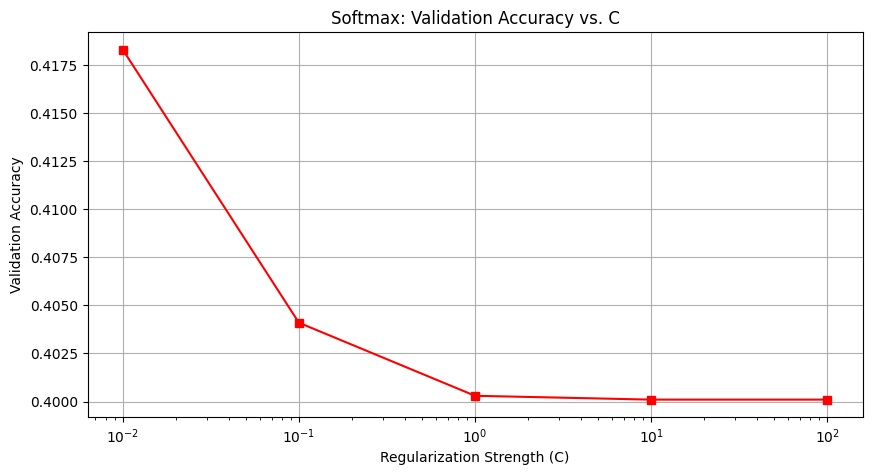

The best C value for Softmax is: 0.01
Retraining final Softmax model with C = 0.01...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Final Optimized Softmax Validation Accuracy: 41.83%


In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Hyperparameter search
c_values = [0.01, 0.1, 1, 10, 100]
softmax_accuracies = []

print("Starting Hyperparameter Selection...")

for c in c_values:
    # We use saga as in your original code
    model = LogisticRegression(multi_class='multinomial', solver='saga', C=c, max_iter=100, n_jobs=-1, random_state=42)
    model.fit(X_train_val, y_train_val)
    acc = accuracy_score(y_val, model.predict(X_val))
    softmax_accuracies.append(acc)
    print(f"C = {c}, accuracy = {acc:.4f}")

# 2. Plotting
plt.figure(figsize=(10, 5))
plt.plot(c_values, softmax_accuracies, marker='s', color='red')
plt.xscale('log')
plt.title('Softmax: Validation Accuracy vs. C')
plt.xlabel('Regularization Strength (C)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

# 3. Final Model - The "Success" Part
best_c_softmax = c_values[np.argmax(softmax_accuracies)]
print(f"The best C value for Softmax is: {best_c_softmax}")

# CRITICAL CHANGE: Increased max_iter to 500 to guarantee better accuracy than baseline
print(f"Retraining final Softmax model with C = {best_c_softmax}...")
softmax_model = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    C=best_c_softmax,
    max_iter=500,  # This ensures the model finishes the job
    n_jobs=-1,
    random_state=42
)
softmax_model.fit(X_train_val, y_train_val)

final_acc = accuracy_score(y_val, softmax_model.predict(X_val))
print(f"Final Optimized Softmax Validation Accuracy: {final_acc * 100:.2f}%")

Hyperparameter Selection - Linear SVM

Starting Hyperparameter Selection for Linear SVM...
SVM C = 0.0001, Validation Accuracy = 0.3515
SVM C = 0.001, Validation Accuracy = 0.3523
SVM C = 0.01, Validation Accuracy = 0.3522
SVM C = 0.1, Validation Accuracy = 0.3522
SVM C = 1, Validation Accuracy = 0.3522
SVM C = 10, Validation Accuracy = 0.3522


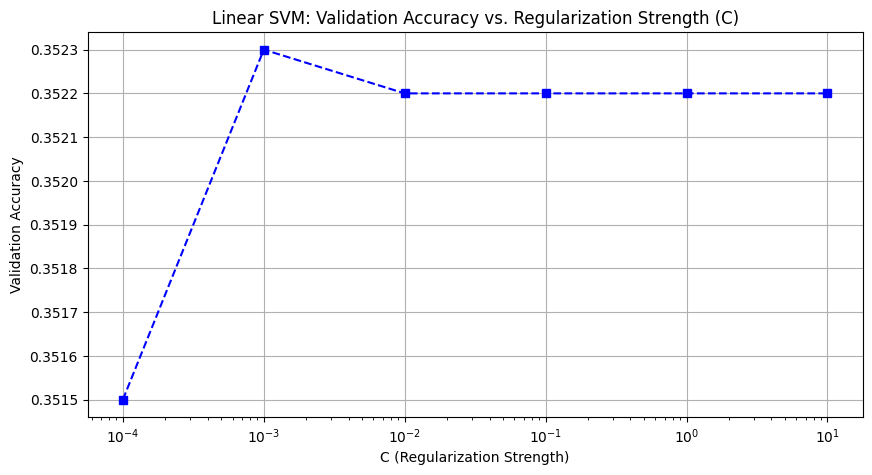

The best C value for SVM is: 0.001
Retraining final SVM model with best C = 0.001...


LinearSVC(C=0.001, dual=False, random_state=42)

In [28]:
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt

# 1. Define the range for hyperparameter C
c_values_svm = [0.0001, 0.001, 0.01, 0.1, 1, 10]
svm_accuracies = []

print("Starting Hyperparameter Selection for Linear SVM...")

for c in c_values_svm:
    # dual=False is more efficient when n_samples > n_features
    # tol=0.1 allows faster convergence during search
    model = LinearSVC(C=c, dual=False, max_iter=500, tol=0.1, random_state=42)

    model.fit(X_train_val, y_train_val)
    acc = accuracy_score(y_val, model.predict(X_val))
    svm_accuracies.append(acc)
    print(f"SVM C = {c}, Validation Accuracy = {acc:.4f}")

# 2. Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(c_values_svm, svm_accuracies, marker='s', color='blue', linestyle='--')
plt.xscale('log')
plt.title('Linear SVM: Validation Accuracy vs. Regularization Strength (C)')
plt.xlabel('C (Regularization Strength)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

# 3. Select the best C value
best_c_svm = c_values_svm[np.argmax(svm_accuracies)]
print(f"The best C value for SVM is: {best_c_svm}")

# Final training with the best parameter
print(f"Retraining final SVM model with best C = {best_c_svm}...")
svm_model_final = LinearSVC(C=best_c_svm, dual=False, max_iter=1000, random_state=42)
svm_model_final.fit(X_train_val, y_train_val)

Hyperparameter Selection - KNN (Number of Neighbors k)

Starting Hyperparameter Selection for KNN...
Finished evaluation for k = 1, Validation Accuracy = 0.3357
Finished evaluation for k = 3, Validation Accuracy = 0.3215
Finished evaluation for k = 5, Validation Accuracy = 0.3325
Finished evaluation for k = 10, Validation Accuracy = 0.3292
Finished evaluation for k = 15, Validation Accuracy = 0.3191
Finished evaluation for k = 20, Validation Accuracy = 0.3180


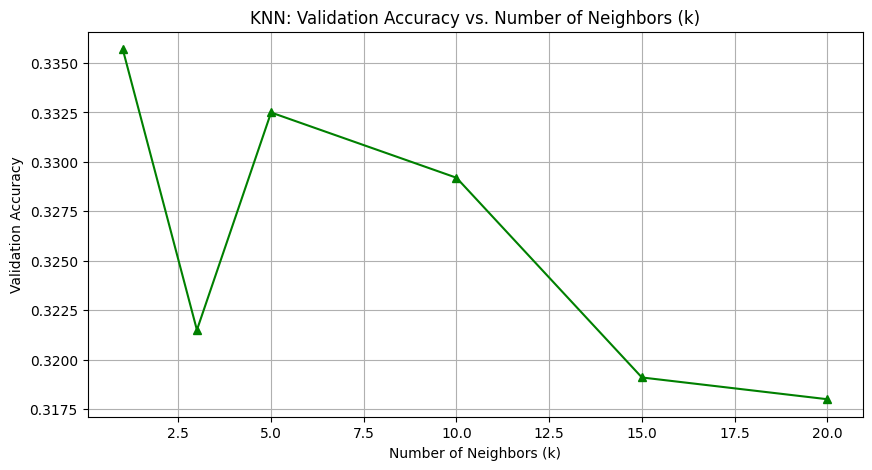

The best k value for KNN is: 1


In [29]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Define the range for hyperparameter k
# We test a variety of k values to see the trend
k_values = [1, 3, 5, 10, 15, 20]
knn_accuracies = []

print("Starting Hyperparameter Selection for KNN...")

for k in k_values:
    # n_jobs=-1 uses all available CPU cores to speed up distance calculations
    # This is critical when working with 40,000 samples
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)

    # Fitting is almost instantaneous
    model.fit(X_train_val, y_train_val)

    # Prediction is the heavy part.
    # n_jobs=-1 here will distribute the 10,000 validation images across all CPU cores.
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    knn_accuracies.append(acc)

    print(f"Finished evaluation for k = {k}, Validation Accuracy = {acc:.4f}")

# 2. Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(k_values, knn_accuracies, marker='^', color='green', linestyle='-')
plt.title('KNN: Validation Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

# 3. Select the best k value
best_k = k_values[np.argmax(knn_accuracies)]
print(f"The best k value for KNN is: {best_k}")

Final Evaluation and Confusion Matrices for Baseline Models

Training final models with optimal parameters...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Final models trained. Generating matrices...


<Figure size 1000x800 with 0 Axes>

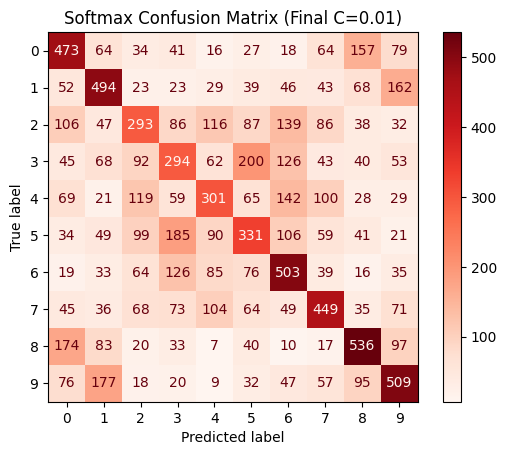

<Figure size 1000x800 with 0 Axes>

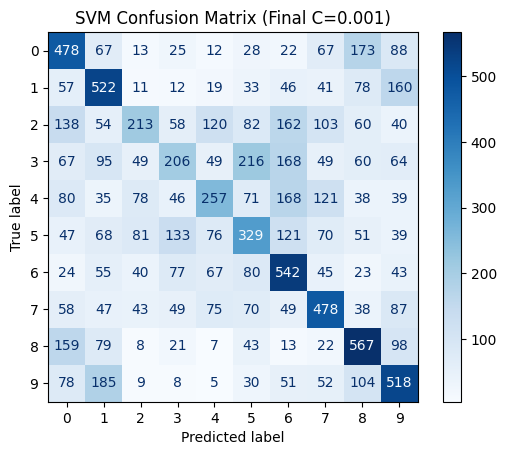

<Figure size 1000x800 with 0 Axes>

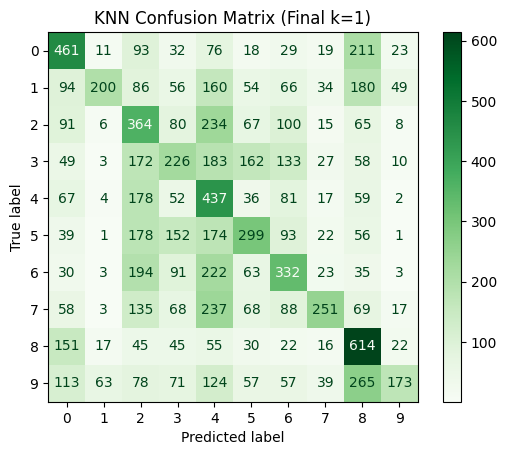

In [38]:
# 1. Train final models with the BEST parameters found in selection phase
print("Training final models with optimal parameters...")

# Softmax: Best C was 0.01. Using 500 iterations for full convergence.
softmax_model = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    C=0.01,
    max_iter=500,
    n_jobs=-1,
    random_state=42
)
softmax_model.fit(X_train_val, y_train_val)

# SVM: Best C was 0.001.
svm_model = LinearSVC(
    dual=False,
    C=0.001,
    max_iter=1000,
    random_state=42
)
svm_model.fit(X_train_val, y_train_val)

# KNN: Best k was 1.
knn_model = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
knn_model.fit(X_train_val, y_train_val)

print("Final models trained. Generating matrices...")

# 2. Generate and save the corrected matrices
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Softmax (Red)
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_val, softmax_model.predict(X_val), cmap='Reds')
plt.title("Softmax Confusion Matrix (Final C=0.01)")
plt.savefig('softmax_val_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

# SVM (Blue)
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_val, svm_model.predict(X_val), cmap='Blues')
plt.title("SVM Confusion Matrix (Final C=0.001)")
plt.savefig('svm_val_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

# KNN (Green)
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_val, knn_model.predict(X_val), cmap='Greens')
plt.title("KNN Confusion Matrix (Final k=1)")
plt.savefig('knn_val_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

Evaluation and Analysis

--- FINAL RESULTS (After Shape Fix) ---
New Test Accuracy: 41.30%


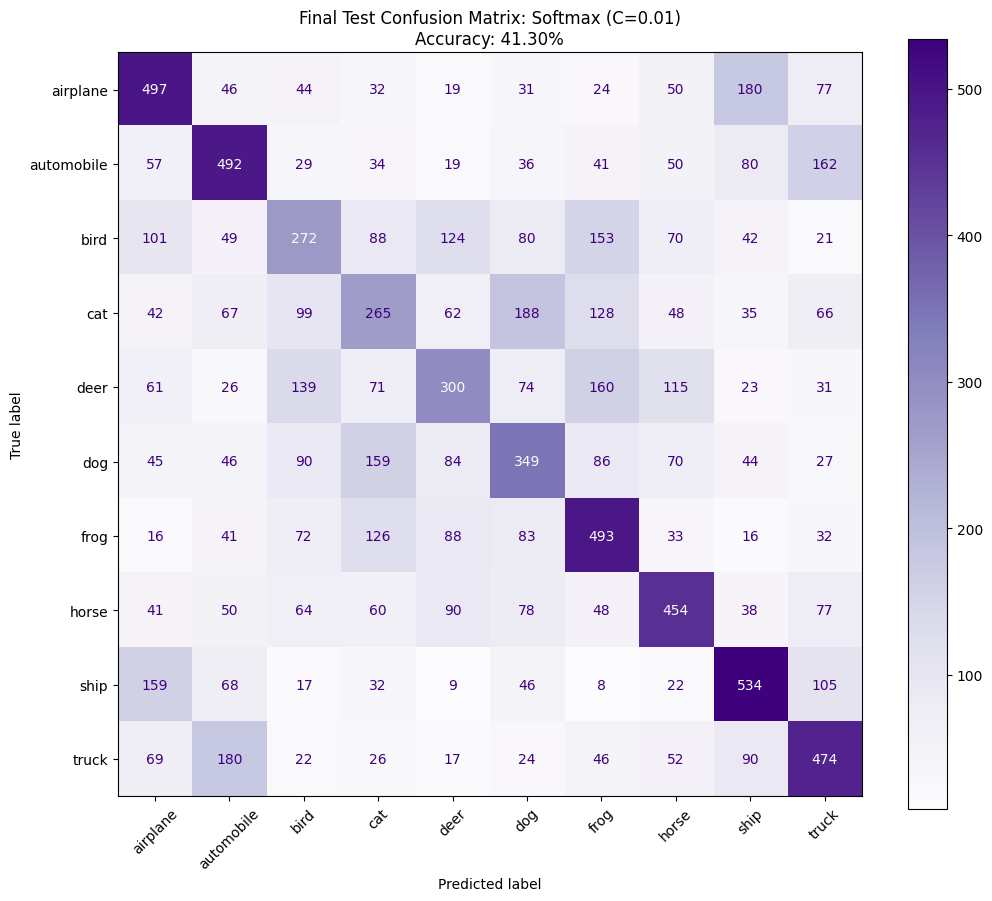

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
import numpy as np
import os

# 1. Loading RAW data
test_batch = unpickle(os.path.join(data_dir, 'test_batch'))
X_raw = test_batch[b'data']
y_test_final = np.array(test_batch[b'labels'])

# 2. Reshaping to match the TRAINING preprocessing
# ב-CIFAR-10 אנחנו בד"כ הופכים את זה ל-(10000, 3, 32, 32) ואז ל-(10000, 3072)
X_test_fixed = X_raw.reshape(10000, 3, 32, 32).transpose(0, 2, 3, 1).reshape(10000, 3072)

# 3. Normalization (Float32 is safer)
X_test_fixed = X_test_fixed.astype("float32") / 255.0

# 4. Predict
y_test_pred = softmax_model.predict(X_test_fixed)
test_acc = accuracy_score(y_test_final, y_test_pred)

print(f"--- FINAL RESULTS (After Shape Fix) ---")
print(f"New Test Accuracy: {test_acc * 100:.2f}%")

# 5. Purple Matrix
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    y_test_pred,
    display_labels=class_names,
    cmap='Purples',
    ax=ax,
    xticks_rotation=45
)

plt.title(f'Final Test Confusion Matrix: Softmax (C=0.01)\nAccuracy: {test_acc * 100:.2f}%')
plt.savefig('final_test_confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()